## Load & Inspect

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [5]:
# Visualization Settings


plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [6]:
DATA_PATH = Path("data/house_prices.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [7]:
df.shape

(187531, 21)

In [8]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [10]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area'], dtype='str')


In [11]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='str')


C:\Users\Nasa\AppData\Local\Temp\ipykernel_15768\3910604682.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [12]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [13]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [14]:
missing = df.isna().mean().sort_values(ascending=False)

missing

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [15]:
df.nunique().sort_values(ascending=False)

Index                187531
Description           65634
Title                 32446
Price (in rupees)     10958
Society               10376
Super Area             2976
Carpet Area            2758
Amount(in rupees)      1561
Floor                   947
Car Parking             229
location                 81
overlooking              19
Bathroom                 11
Balcony                  11
facing                    8
Transaction               4
Ownership                 4
Furnishing                3
Status                    1
Dimensions                0
Plot Area                 0
dtype: int64

**How many rows? Which columns are numeric vs text? 
Which columns have the most missing values?**

the dataset contains 187,531 rows and 21 columns        
*Numeric columns:*                    
Index → int64
Price (in rupees) → float64
Dimensions → float64
Plot Area → float64
The remaining 17 columns are stored as str is text              
*the columns with the most missing values are:*
[Dimensions,Plot Area,Society,Super Area,Car Parking,overlooking,Carpet Area,facing,Ownership]
So, the biggest issue is that Dimensions and Plot Area are completely empty, while Society, Super Area, Car Parking, overlooking, Carpet Area, facing, and Ownership have substantial missing data.

## Exploratory Data Analysis (EDA)

In [16]:
df["Amount(in rupees)"].head(20)

0       42 Lac 
1       98 Lac 
2      1.40 Cr 
3       25 Lac 
4      1.60 Cr 
5       45 Lac 
6     16.5 Lac 
7       60 Lac 
8       60 Lac 
9      1.60 Cr 
10     1.40 Cr 
11     1.36 Cr 
12     1.35 Cr 
13     4.25 Cr 
14      75 Lac 
15      90 Lac 
16      37 Lac 
17      35 Lac 
18      90 Lac 
19      35 Lac 
Name: Amount(in rupees), dtype: str

In [17]:
df["Amount(in rupees)"].sample(20, random_state=42)

99649      1.20 Cr 
20299       65 Lac 
153392      98 Lac 
104329     1.20 Cr 
174711    44.4 Lac 
107506     1.10 Cr 
149672      24 Lac 
38670       63 Lac 
167536     1.30 Cr 
156041    28.1 Lac 
116842       16 Cr 
6345        52 Lac 
145640    25.7 Lac 
146409      18 Lac 
154277      75 Lac 
60322      1.05 Cr 
164255      50 Lac 
150879    78.5 Lac 
14907       64 Lac 
99222     18.3 Lac 
Name: Amount(in rupees), dtype: str

In [18]:
df["Price (in rupees)"].head(20)

0      6000.0
1     13799.0
2     17500.0
3         NaN
4     18824.0
5      6618.0
6      2538.0
7     10435.0
8     10000.0
9     11150.0
10    12174.0
11    11674.0
12    15995.0
13    17526.0
14    11538.0
15    10000.0
16     5736.0
17     6481.0
18    11250.0
19     6731.0
Name: Price (in rupees), dtype: float64

In [19]:
df["Price (in rupees)"].describe()

count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

In [20]:
df[["Amount(in rupees)", "Price (in rupees)"]].head(20)

,Amount(in rupees),Price (in rupees)
0,42 Lac,6000.0
1,98 Lac,13799.0
2,1.40 Cr,17500.0
3,25 Lac,NaN
4,1.60 Cr,18824.0
5,45 Lac,6618.0
6,16.5 Lac,2538.0
7,60 Lac,10435.0
8,60 Lac,10000.0
9,1.60 Cr,11150.0


In [21]:
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None

In [22]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [23]:
df[["Amount(in rupees)", "price_clean"]].head(20)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [24]:
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [25]:
df["Furnishing"].value_counts(dropna=False)

Furnishing
Semi-Furnished    88318
Unfurnished       76154
Furnished         20162
NaN                2897
Name: count, dtype: int64

In [26]:
df["Transaction"].value_counts(dropna=False)

Transaction
Resale          144172
New Property     42565
Other              709
NaN                 83
Rent/Lease           2
Name: count, dtype: int64

In [27]:
df["Ownership"].value_counts(dropna=False)

Ownership
Freehold                112229
NaN                      65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [28]:
df["Status"].value_counts(dropna=False)

Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64

In [29]:
df["Status"].value_counts(dropna=False)

Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64

In [30]:
df["location"].value_counts().head(20)

location
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
vadodara          2388
surat             2370
pune              2225
thane             1933
mumbai            1860
visakhapatnam     1800
mohali            1710
zirakpur          1530
chandigarh        1440
noida             1281
Name: count, dtype: int64

In [31]:
df["Carpet Area"].dropna().sample(20, random_state=42)

117744    1200 sqft
51145     1810 sqft
153735    1195 sqft
165792     853 sqft
29320     1000 sqft
73081     3600 sqft
87618     1250 sqft
48393     3440 sqft
53234     2358 sqft
156651     835 sqft
48441     1831 sqft
109157    2550 sqft
157592    1150 sqft
138006     450 sqft
43860      800 sqft
119319      7 sqyrd
135506    2027 sqft
3881       615 sqft
33820     1000 sqft
143073    1870 sqft
Name: Carpet Area, dtype: str

In [32]:
df["Super Area"].dropna().sample(20, random_state=42)

171479    1400 sqft
167349     538 sqft
118652     45 sqyrd
81955     1100 sqft
169576    2229 sqft
38746     1285 sqft
130472     45 sqyrd
158779    1895 sqft
37078     3350 sqft
103546    1435 sqft
36288     1140 sqft
36043      910 sqft
40627      569 sqft
11401     218 sqyrd
152997    1579 sqft
37966     1285 sqft
174682    1500 sqft
51516     2802 sqft
22285     1332 sqft
97006     1435 sqft
Name: Super Area, dtype: str

In [33]:
df["Floor"].dropna().sample(30, random_state=42)

60143         5 out of 13
49876          2 out of 2
1673           2 out of 9
31677        19 out of 20
26269          4 out of 4
34004          2 out of 4
11548          1 out of 3
20298          3 out of 4
35378        10 out of 14
167026         1 out of 4
181234         5 out of 9
27806          2 out of 4
79041          4 out of 5
24540          3 out of 6
19296     Ground out of 4
104216         5 out of 5
100346         5 out of 5
141812         3 out of 4
156222        2 out of 12
110420         3 out of 3
10361          2 out of 5
120491        8 out of 10
2708           5 out of 9
133667        3 out of 10
147151       12 out of 23
176127         1 out of 4
101112         4 out of 5
85957     Ground out of 6
182104         3 out of 5
147328       10 out of 24
Name: Floor, dtype: str

In [34]:
df["Bathroom"].value_counts(dropna=False).head(20)

Bathroom
2       93007
3       55781
1       18654
4       15600
5        3343
NaN       828
6         209
> 10       35
7          35
10         14
8          14
9          11
Name: count, dtype: int64

In [35]:
df["Balcony"].value_counts(dropna=False).head(20)

Balcony
2       51809
1       49219
NaN     48935
3       27111
4        9420
5         841
6         132
> 10       22
7          14
10         13
8          13
9           2
Name: count, dtype: int64

In [36]:
df["Car Parking"].value_counts(dropna=False).head(20)

Car Parking
NaN            103357
1 Covered       38754
1 Covered,      16991
2 Covered       10691
1 Open           7873
2 Covered,       3978
2 Open           2589
10 Open           846
34 Covered        573
3 Covered         408
402 Covered       318
8 Covered         206
3 Covered,        140
4 Covered         116
3 Open             37
5 Covered          35
4 Covered,         29
4 Open             27
5 Open             24
6 Covered          24
Name: count, dtype: int64

In [37]:
#convert_area_to_sqft
import re
import numpy as np

def convert_area_to_sqft(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    match = re.search(r"([\d.]+)", x)

    if not match:
        return np.nan

    value = float(match.group(1))

    if "sqm" in x or "sq. m" in x:
        return value * 10.764

    return value


df["carpet_area_sqft"] = df["Carpet Area"].apply(convert_area_to_sqft)

In [38]:
# Compare original and cleaned values
df[["Carpet Area", "carpet_area_sqft"]].sample(10, random_state=42)

,Carpet Area,carpet_area_sqft
99649,740 sqft,740.0
20299,1050 sqft,1050.0
153392,NaN,NaN
104329,740 sqft,740.0
174711,1300 sqft,1300.0
107506,NaN,NaN
149672,NaN,NaN
38670,1435 sqft,1435.0
167536,NaN,NaN
156041,NaN,NaN


### Distribution of House Prices

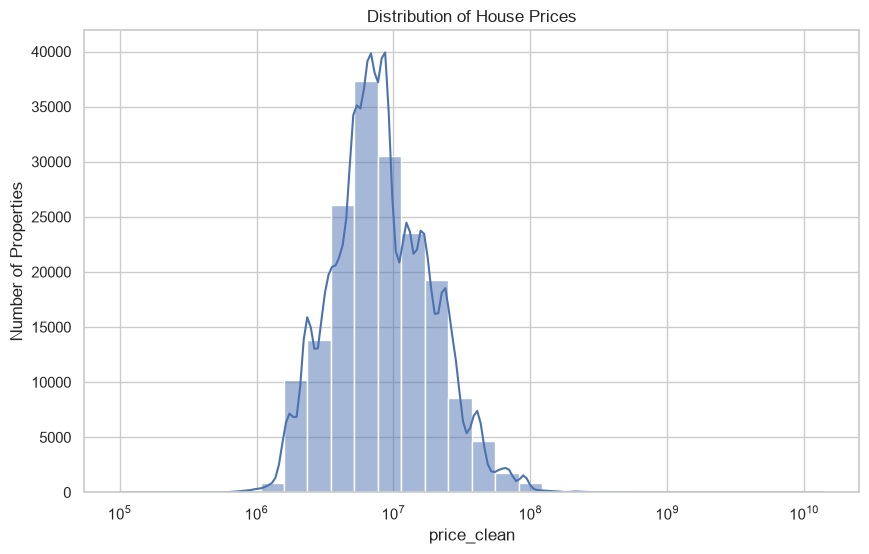

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(df["price_clean"], bins=30, kde=True,log_scale=True)

plt.title("Distribution of House Prices")

plt.xlabel("price_clean")

plt.ylabel("Number of Properties")

plt.show()

Most houses are concentrated within a specific price range, while a smaller number of properties have very high prices. This indicates the presence of high-value outliers

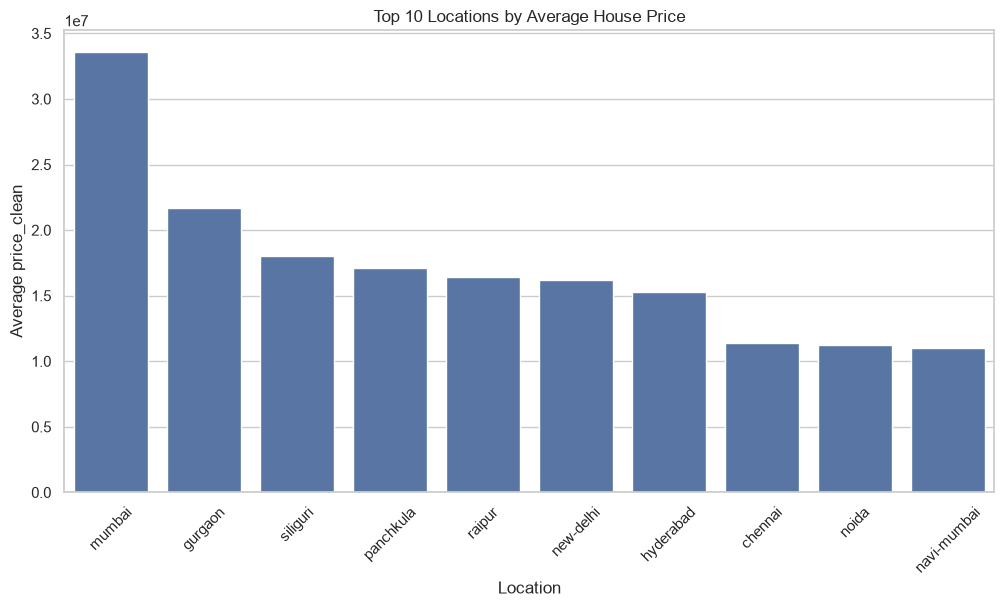

In [40]:
#Top 10 Locations by Average Price

top_locations = (
    df.groupby("location")["price_clean"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.title("Top 10 Locations by Average House Price")

plt.xlabel("Location")

plt.ylabel("Average price_clean")

plt.xticks(rotation=45)

plt.show()

The average house prices vary significantly across different locations. Some locations have considerably higher average prices, indicating that location is an important factor affecting house prices

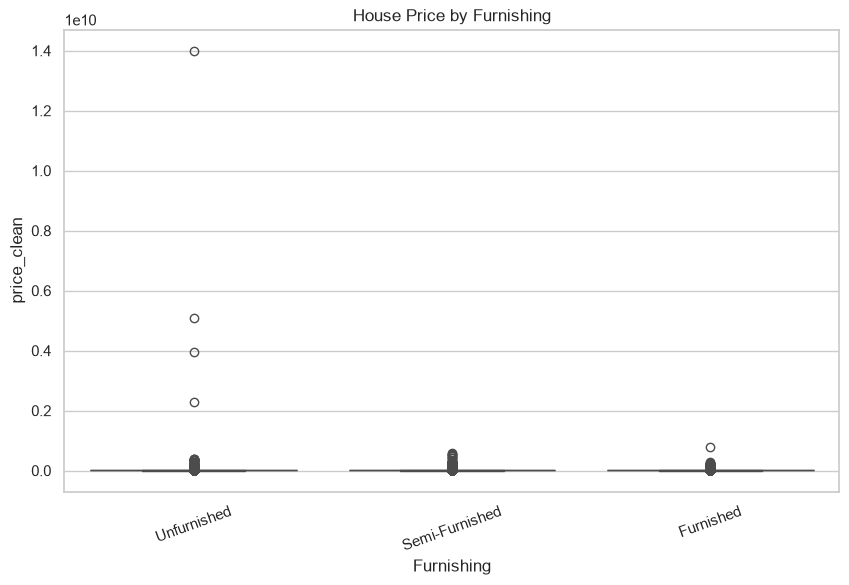

In [41]:
# House Price by Furnishing


plt.figure(figsize=(10,6))

sns.boxplot(
    x="Furnishing",
    y="price_clean",
    data=df
)

plt.title("House Price by Furnishing")

plt.xlabel("Furnishing")

plt.ylabel("price_clean")

plt.xticks(rotation=20)

plt.show()

Furnishing status appears to influence house prices. Fully furnished properties generally tend to have higher prices compared to semi-furnished or unfurnished properties

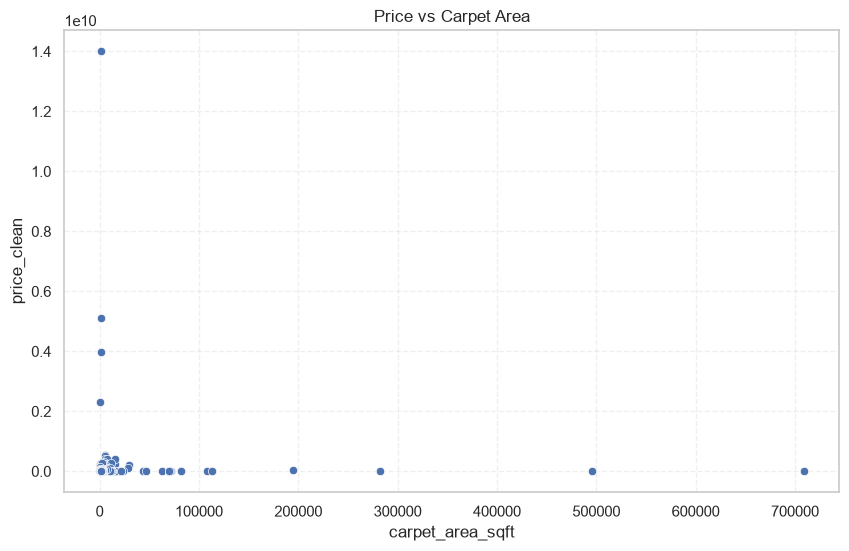

In [42]:
# Price vs Carpet Area


plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["carpet_area_sqft"],
    y=df["price_clean"]
)

plt.title("Price vs Carpet Area")

plt.xlabel("carpet_area_sqft")

plt.ylabel("price_clean")

#plt.xscale("log")
#plt.yscale("log")

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)
plt.show()

The scatter plot shows a positive relationship between carpet area and house price in general, but the relationship is difficult to observe clearly because of several extreme values. Some properties have unusually large carpet areas and very high prices, which significantly affect the scale of the plot,although some outliers may exist

## Data Cleaning & Feature Engineering

In [43]:
df_clean= df.copy()

In [44]:
df_clean["price_clean"].isna().sum()

np.int64(9684)

In [45]:
df_clean = df_clean.dropna(subset=["price_clean"])

In [46]:
print(df_clean.shape)

(177847, 23)


In [47]:
df_clean["carpet_area_sqft"].isna().sum()

np.int64(76325)

In [48]:
df_clean[df_clean["carpet_area_sqft"].isna()]["Carpet Area"].value_counts().head(30)

Series([], Name: count, dtype: int64)

In [49]:
# Convert Super Area into square feet
df_clean["Super_Area_sqft"] = df_clean["Super Area"].apply(convert_area_to_sqft)

In [50]:
df_clean[["Super Area", "Super_Area_sqft"]].sample(10, random_state=42)


,Super Area,Super_Area_sqft
61113,1149 sqft,1149.0
155818,NaN,NaN
172589,1025 sqft,1025.0
120110,NaN,NaN
154003,NaN,NaN
99959,1017 sqft,1017.0
6909,NaN,NaN
4313,NaN,NaN
82180,1250 sqft,1250.0
102315,NaN,NaN


In [51]:
# Display unsupported area units that were converted to missing values
df_clean[df_clean["Super_Area_sqft"].isna()]["Super Area"].value_counts()


Series([], Name: count, dtype: int64)

In [52]:
# Display random unique floor formats
pd.Series(df_clean["Floor"].dropna().unique()).sample(50, random_state=42)

70                  5 out of 12
331                 8 out of 14
858                45 out of 45
495                18 out of 39
209                19 out of 20
863                11 out of 45
30                  1 out of 27
893                11 out of 84
250                 6 out of 22
541                18 out of 35
689                24 out of 27
86                   1 out of 6
708     Upper Basement out of 6
136                19 out of 24
39                  7 out of 16
351                16 out of 29
137                 7 out of 19
693                 3 out of 26
444                28 out of 60
753                17 out of 33
720                           3
247                 5 out of 27
239                17 out of 30
857                27 out of 33
887                21 out of 31
915                 2 out of 67
439                13 out of 36
675            Ground out of 18
759                 7 out of 40
306                 2 out of 11
280                13 out of 42
717     

In [53]:
# Convert floor information into numeric features
def parse_floor(floor):


    if pd.isna(floor):
        return np.nan, np.nan

    # Convert the value to string and remove extra spaces
    floor = str(floor).strip()

    # Handle Ground Floor
    if "Ground" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return 0, int(match.group(1))

        return 0, np.nan

    # Handle Upper Basement
    if "Upper Basement" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return -1, int(match.group(1))

        return -1, np.nan

    # Handle Lower Basement
    if "Lower Basement" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return -2, int(match.group(1))

        return -2, np.nan

    # Handle values in the format "X out of Y"
    match = re.match(r"(\d+)\s+out of\s+(\d+)", floor)

    if match:
        floor_number = int(match.group(1))
        total_floors = int(match.group(2))

        return floor_number, total_floors

    # Handle values that contain only the floor number
    if floor.isdigit():
        return int(floor), np.nan

    # Return missing values for unsupported formats
    return np.nan, np.nan

In [54]:
# Apply the function to extract floor information
df_clean[["Floor_Number", "Total_Floors"]] = df_clean["Floor"].apply(
    lambda x: pd.Series(parse_floor(x))
)

In [55]:
# Compare the original and cleaned floor columns
df_clean[["Floor", "Floor_Number", "Total_Floors"]].sample(10, random_state=42)

,Floor,Floor_Number,Total_Floors
61113,Ground out of 2,0.0,2.0
155818,4 out of 4,4.0,4.0
172589,10 out of 12,10.0,12.0
120110,7 out of 10,7.0,10.0
154003,2 out of 2,2.0,2.0
99959,1 out of 7,1.0,7.0
6909,6 out of 14,6.0,14.0
4313,2 out of 4,2.0,4.0
82180,4 out of 9,4.0,9.0
102315,Ground out of 5,0.0,5.0


In [56]:
# Clean the Bathroom column and convert it to numeric values

df_clean["Bathroom"] = df_clean["Bathroom"].replace("> 10", np.nan)

df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"])

In [57]:
print(df_clean["Bathroom"].dtype)

print(df_clean["Bathroom"].unique())

float64
[ 1.  2.  3.  4.  6. nan  5.  9.  8.  7. 10.]


In [58]:
# Clean the Balcony column and convert it to numeric values

df_clean["Balcony"] = df_clean["Balcony"].replace("> 10", np.nan)

df_clean["Balcony"] = pd.to_numeric(df_clean["Balcony"])

print(df_clean["Balcony"].dtype)
print(df_clean["Balcony"].unique())

float64
[ 2. nan  1.  3.  4.  6.  5.  7. 10.  8.  9.]


In [59]:
# Explore and clean the Car Parking column

display(df_clean["Car Parking"].head(10))

display(df_clean["Car Parking"].value_counts().head(20))

0          NaN
1       1 Open
2    1 Covered
3          NaN
4    1 Covered
5          NaN
6          NaN
7          NaN
8          NaN
9    1 Covered
Name: Car Parking, dtype: str

Car Parking
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
3 Covered,       138
4 Covered        109
5 Covered         33
3 Open            32
4 Covered,        27
4 Open            26
15 Covered        24
5 Open            23
6 Covered         23
8 Covered         22
Name: count, dtype: int64

In [60]:
 # Extract the number of parking spaces and convert it to numeric

df_clean["Car Parking"] = (
    df_clean["Car Parking"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df_clean["Car Parking"] = pd.to_numeric(df_clean["Car Parking"])
print(df_clean["Car Parking"].dtype)
print(df_clean["Car Parking"].head(10))

float64
0    NaN
1    1.0
2    1.0
3    NaN
4    1.0
5    NaN
6    NaN
7    NaN
8    NaN
9    1.0
Name: Car Parking, dtype: float64


#### Drop Useless Columns

In [61]:
# Drop columns that contain only missing values

df_clean = df_clean.drop(columns=["Dimensions", "Plot Area"])

In [62]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177058 non-null  float64
 15  Balcony            130672 non-null  float64
 16  Car Parking       

In [63]:
# Drop text columns that will not be used for machine learning

df_clean = df_clean.drop(columns=["Title", "Description"])

In [64]:
# Explore the location column

display(df_clean["location"].head(10))

print(df_clean["location"].nunique())

display(df_clean["location"].value_counts().head(20))

0    thane
1    thane
2    thane
3    thane
4    thane
5    thane
6    thane
7    thane
8    thane
9    thane
Name: location, dtype: str

81


location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
Name: count, dtype: int64

In [65]:
# Explore the Society column

display(df_clean["Society"].head(10))

print(df_clean["Society"].nunique())

display(df_clean["Society"].value_counts().head(20))

0    Srushti Siddhi Mangal Murti Complex
1                            Dosti Vihar
2                   Sunrise by Kalpataru
3                                    NaN
4            TenX Habitat Raymond Realty
5                           Virat Aangan
6                                    NaN
7                                    NaN
8                                    NaN
9                            Pride Palms
Name: Society, dtype: str

10068


Society
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
DDA Flat                         823
Rama Apartment                   823
Aadarsh Apartment                821
CGHS Apoorva Apartments          821
Him Hit Sadbhavna Apartments     821
DDA Sanskriti Apartments         821
Madhur Jeevan Apartment          821
Kesarwani Apartment              821
DLF New Town Heights             666
Elita Garden Vista               655
Mani Casa                        653
Name: count, dtype: int64

In [66]:
# Keep only the top 50 most frequent societies

top_societies = df_clean["Society"].value_counts().head(50).index

df_clean["Society"] = df_clean["Society"].apply(
    lambda x: x if x in top_societies else "Other"
)

In [67]:
# Validate the Society column after grouping rare categories

print(df_clean["Society"].nunique())

display(df_clean["Society"].value_counts().head(20))

51


Society
Other                           141671
Hamdam Apartment                  1648
Malibu Town                       1158
Shree Vardhman Victoria           1154
DLF Skycourt                      1153
Nebula Tower                       982
Harmony Apartment                  828
Defence Officers Apartment         827
East of Kailash                    826
Sarve Satyam Apartment             825
DDA Flat                           823
Rama Apartment                     823
Aadarsh Apartment                  821
CGHS Apoorva Apartments            821
Him Hit Sadbhavna Apartments       821
DDA Sanskriti Apartments           821
Madhur Jeevan Apartment            821
Kesarwani Apartment                821
DLF New Town Heights               666
Elita Garden Vista                 655
Name: count, dtype: int64

### Data Preprocessing

In [68]:
# Drop original columns after creating their cleaned numeric versions

df_clean = df_clean.drop(columns=[
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor"
])

In [69]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Price (in rupees)  169866 non-null  float64
 2   location           177847 non-null  str    
 3   Status             177252 non-null  str    
 4   Transaction        177780 non-null  str    
 5   Furnishing         175780 non-null  str    
 6   facing             112111 non-null  str    
 7   overlooking        102022 non-null  str    
 8   Society            177847 non-null  str    
 9   Bathroom           177058 non-null  float64
 10  Balcony            130672 non-null  float64
 11  Car Parking        81935 non-null   float64
 12  Ownership          115922 non-null  str    
 13  price_clean        177847 non-null  float64
 14  carpet_area_sqft   101522 non-null  float64
 15  Super_Area_sqft    76235 non-null   float64
 16  Floor_Number      

In [70]:
# Fill missing values in numeric columns using the median

numeric_columns = [
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Floor_Number",
    "Total_Floors"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean[numeric_columns].isna().sum()

Bathroom        0
Balcony         0
Car Parking     0
Floor_Number    0
Total_Floors    0
dtype: int64

In [71]:
# Fill missing values in categorical columns using the mode

categorical_columns = [
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean[categorical_columns].isna().sum()

Status         0
Transaction    0
Furnishing     0
facing         0
overlooking    0
Ownership      0
dtype: int64

In [72]:
# Check missing values 

missing_values = df_clean.isna().sum().sort_values(ascending=False)

display(missing_values[missing_values > 0])

Super_Area_sqft      101612
carpet_area_sqft      76325
Price (in rupees)      7981
dtype: int64

In [73]:
df_clean["Area_sqft"] = df_clean["Super_Area_sqft"].fillna(df_clean["carpet_area_sqft"])

In [74]:
# Compare the original area columns with the temporary area feature

df_clean[
    ["Super_Area_sqft", "carpet_area_sqft", "Area_sqft"]
].sample(10, random_state=42)

,Super_Area_sqft,carpet_area_sqft,Area_sqft
61113,1149.0,NaN,1149.0
155818,NaN,900.0,900.0
172589,1025.0,NaN,1025.0
120110,NaN,1600.0,1600.0
154003,NaN,1160.0,1160.0
99959,1017.0,NaN,1017.0
6909,NaN,1707.0,1707.0
4313,NaN,372.0,372.0
82180,1250.0,NaN,1250.0
102315,NaN,500.0,500.0


In [75]:
# Calculate the temporary price per square foot feature

df_clean["Price_per_sqft"] = (
    df_clean["price_clean"] / df_clean["Area_sqft"]
)
df_clean["Price_per_sqft"].describe()

count    1.777570e+05
mean     1.608967e+04
std      3.750214e+05
min      3.830877e+00
25%      4.842105e+03
50%      6.923077e+03
75%      1.131419e+04
max      5.454545e+07
Name: Price_per_sqft, dtype: float64

In [76]:
# Calculate the lower and upper percentile thresholds

lower_limit = df_clean["Price_per_sqft"].quantile(0.01)
upper_limit = df_clean["Price_per_sqft"].quantile(0.99)

print(f"1st Percentile : {lower_limit:.2f}")
print(f"99th Percentile: {upper_limit:.2f}")

1st Percentile : 2286.15
99th Percentile: 101503.76


In [77]:
# Remove listings with extreme price per square foot values

df_clean = df_clean[
    (df_clean["Price_per_sqft"] >= lower_limit) &
    (df_clean["Price_per_sqft"] <= upper_limit)
]

In [78]:
print(f"Dataset shape: {df_clean.shape}")
print(f"Rows removed: {177847 - len(df_clean)}")

Dataset shape: (174438, 20)
Rows removed: 3409


In [79]:
df_clean = df_clean.drop(columns=["Area_sqft", "Price_per_sqft"]) #used for outlier detection

In [80]:
"Area_sqft" in df_clean.columns, "Price_per_sqft" in df_clean.columns

(False, False)

In [81]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 174438 entries, 0 to 187530
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              174438 non-null  int64  
 1   Price (in rupees)  166613 non-null  float64
 2   location           174438 non-null  str    
 3   Status             174438 non-null  str    
 4   Transaction        174438 non-null  str    
 5   Furnishing         174438 non-null  str    
 6   facing             174438 non-null  str    
 7   overlooking        174438 non-null  str    
 8   Society            174438 non-null  str    
 9   Bathroom           174438 non-null  float64
 10  Balcony            174438 non-null  float64
 11  Car Parking        174438 non-null  float64
 12  Ownership          174438 non-null  str    
 13  price_clean        174438 non-null  float64
 14  carpet_area_sqft   100537 non-null  float64
 15  Super_Area_sqft    73901 non-null   float64
 16  Floor_Number      

In [82]:
print(df_clean.shape)

(174438, 18)


### Data Cleaning & Feature Engineering Summary

1. Converted the property price from text to a numeric format 

2. Standardized the area features and converted all values to square feet (sqft)

3. Extracted floor information into numeric features

4. Converted Bathroom, Balcony, and Car Parking to numeric values and handled missing values

5. Reduced the cardinality of the location and Society features by keeping the top 50 categories and grouping the remaining values as Other

6. Removed unnecessary columns

7. Detected and removed outliers using the Price per sqft feature

## Build, Train & Evaluate the Machine Learning Models

In [83]:
import joblib
import json
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [87]:
df_clean.columns

Index(['Index', 'Price (in rupees)', 'location', 'Status', 'Transaction',
       'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony',
       'Car Parking', 'Ownership', 'price_clean', 'carpet_area_sqft',
       'Super_Area_sqft', 'Floor_Number', 'Total_Floors'],
      dtype='str')

In [85]:
# Define feature columns and target

numeric_features = [
    "carpet_area_sqft",
    "Floor_Number",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Total_Floors"
]

categorical_features = [
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]

print("Features selected!")

Features selected!


In [88]:
#  Apply Log Transformation to target (price)
y_log = np.log1p(y)

print("Target transformed using log1p")

Target transformed using log1p


In [89]:
# create standard scaling and one-hot encoding for numeric and categorical features

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())]),
        numeric_features
    ),

    (
        "cat",
        Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
        categorical_features
    )
])

In [90]:
#  Split data into train (80%) and test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test = np.expm1(y_test_log)

print("Data split completed")

Data split completed


### 1. Linear Regression Model

In [91]:
#  Remove invalid target values

valid_mask = (
    ~np.isnan(y_train_log) &
    ~np.isinf(y_train_log)
)

X_train = X_train[valid_mask]
y_train_log = y_train_log[valid_mask]


#  Build Linear Regression Pipeline

model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])


# Train the model

model_lr.fit(X_train, y_train_log)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [92]:
# Predict log prices

y_pred_log = model_lr.predict(X_test)


# Convert predictions back to original price scale

y_pred = np.expm1(y_pred_log)

In [93]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score 

pred = model_lr.predict(X_test) 
print("MAE :", mean_absolute_error(y_test, pred)) 
print("RMSE:", root_mean_squared_error(y_test, pred)) 
print("R² :", r2_score(y_test, pred)) 

MAE : 11791864.661260495
RMSE: 17593787.669373278
R² : -0.8155631779999744


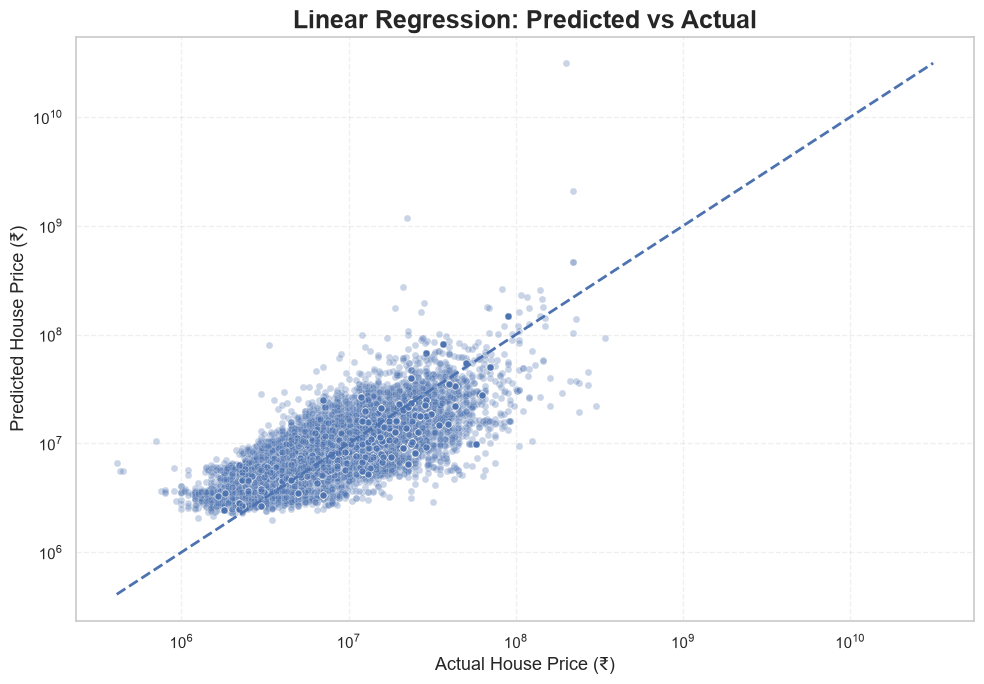

In [103]:
# Linear Regression predictions
y_pred_lr_log = model_lr.predict(X_test)
y_pred_lr = np.expm1(y_pred_lr_log)

# Plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr,
    alpha=0.3,
    s=25
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.title(
    "Linear Regression: Predicted vs Actual",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Actual House Price (₹)", fontsize=13)
plt.ylabel("Predicted House Price (₹)", fontsize=13)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

### 2. Random Forest Model

In [95]:
# Build Random Forest pipeline 
model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
model_rf.fit(X_train, y_train_log)

print("Random Forest trained successfully")

Random Forest trained successfully


In [96]:
# Predict log prices
y_pred_rf_log = model_rf.predict(X_test)

# Convert predictions back to original price
y_pred_rf = np.expm1(y_pred_rf_log)

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
--------------------
MAE : 1641501.8103231941
RMSE: 5810388.129343598
R²  : 0.8019827790745439


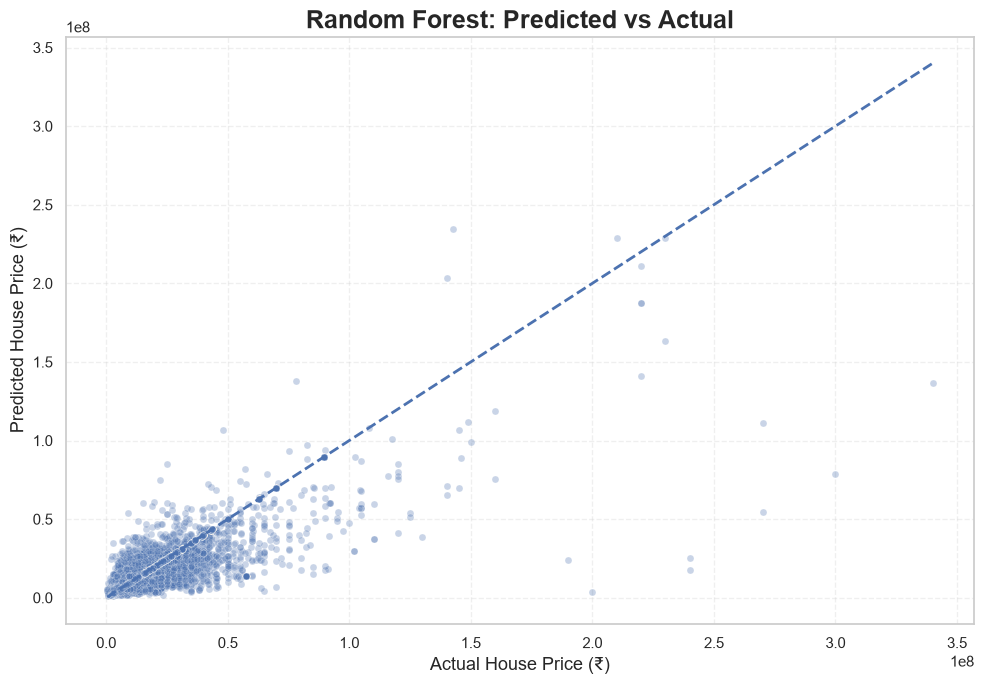

In [104]:
# Random Forest predictions
y_pred_rf_log = model_rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

# Plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.3,
    s=25
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.title(
    "Random Forest: Predicted vs Actual",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Actual House Price (₹)", fontsize=13)
plt.ylabel("Predicted House Price (₹)", fontsize=13)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 3. Gradient Boosting Regressor Model

In [98]:
from sklearn.ensemble import GradientBoostingRegressor

# Build Gradient Boosting pipeline
model_gb = Pipeline([
    ("prep", preprocessor),
    ("reg", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train the model
model_gb.fit(X_train, y_train_log)

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [99]:
# Predict log prices
y_pred_gb_log = model_gb.predict(X_test)

# Convert predictions back to original price
y_pred_gb = np.expm1(y_pred_gb_log)

In [100]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
-------------------------
MAE : 3522234.0005670884
RMSE: 7790707.327460731
R²  : 0.6440029063098323


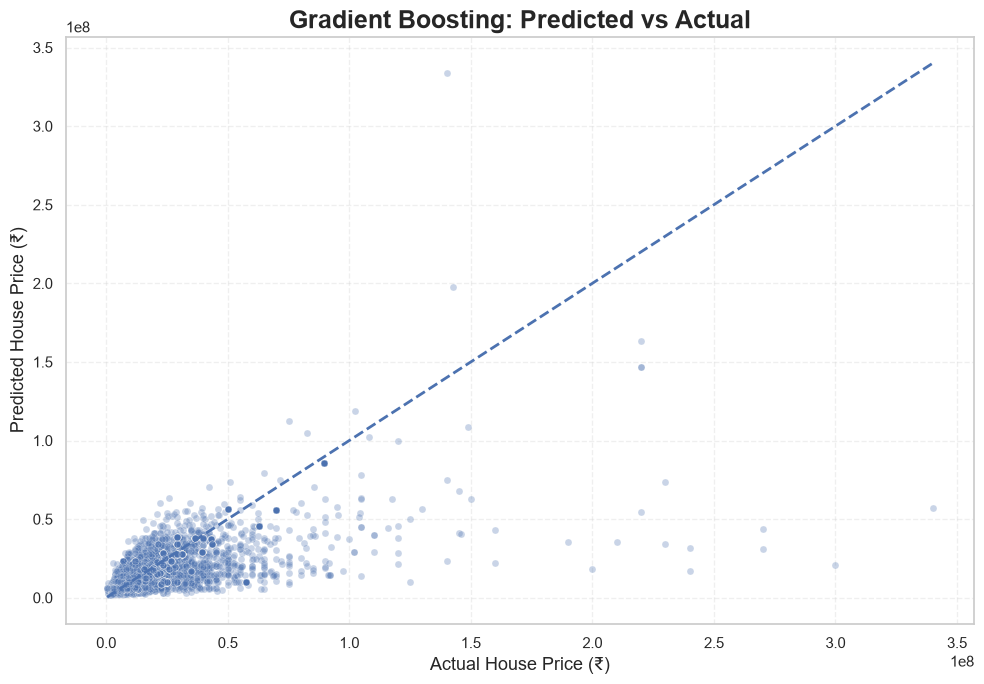

In [105]:
# Gradient Boosting predictions
y_pred_gb_log = model_gb.predict(X_test)
y_pred_gb = np.expm1(y_pred_gb_log)

# Plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred_gb,
    alpha=0.3,
    s=25
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_gb.min())
max_value = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.title(
    "Gradient Boosting: Predicted vs Actual",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Actual House Price (₹)", fontsize=13)
plt.ylabel("Predicted House Price (₹)", fontsize=13)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 3 Models Comparison

In [107]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        mean_absolute_error(y_test, np.expm1(model_lr.predict(X_test))),
        mae_rf,
        mae_gb
    ],
    
    "RMSE": [
        np.sqrt(mean_squared_error(
            y_test,
            np.expm1(model_lr.predict(X_test))
        )),
        rmse_rf,
        rmse_gb
    ],
    
    "R2": [
        r2_score(
            y_test,
            np.expm1(model_lr.predict(X_test))
        ),
        r2_rf,
        r2_gb
    ]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,5.824509e+06,1.674985e+08,-163.556354
1,Random Forest,1.641502e+06,5.810388e+06,0.801983
2,Gradient Boosting,3.522234e+06,7.790707e+06,0.644003


In [109]:
# Sort models by R² descending
results_sorted = results.sort_values(
    by="R2",
    ascending=False
)

print(results_sorted)

               Model           MAE          RMSE          R2
1      Random Forest  1.641502e+06  5.810388e+06    0.801983
2  Gradient Boosting  3.522234e+06  7.790707e+06    0.644003
0  Linear Regression  5.824509e+06  1.674985e+08 -163.556354


In [117]:
# Select the best model based on R²
best_model = results.loc[results["R2"].idxmax(), "Model"]

print("Best Model:", best_model)

Best Model: Random Forest


In [113]:
winner_row = results.loc[results["R2"].idxmax()]

print(
    f"{winner_row['Model']} was selected as the final model.\n"
    
    f"It achieved the highest R² score of "
    f"{winner_row['R2']:.4f}.\n"
    
    f"The model achieved an MAE of "
    f"{winner_row['MAE']:.2f}\n"
    
    f"and an RMSE of "
    f"{winner_row['RMSE']:.2f}.\n"
    
    f"Therefore, it provided the best overall "
    f"predictive performance among the evaluated models."
)

Random Forest was selected as the final model.
It achieved the highest R² score of 0.8020.
The model achieved an MAE of 1641501.81
and an RMSE of 5810388.13.
Therefore, it provided the best overall predictive performance among the evaluated models.


In [119]:
from sklearn.model_selection import cross_val_score

# Number of folds
cv = 5

# Linear Regression
lr_scores = cross_val_score(
    model_lr,
    X_train,
    y_train_log,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# Random Forest
rf_scores = cross_val_score(
    model_rf,
    X_train,
    y_train_log,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# Gradient Boosting
gb_scores = cross_val_score(
    model_gb,
    X_train,
    y_train_log,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)
print("5-Fold Cross-Validation Results")
print("--------------------------------")

print("\nLinear Regression:")
print("Scores:", lr_scores)
print("Mean R²:", lr_scores.mean())
print("Std R² :", lr_scores.std())

print("\nRandom Forest:")
print("Scores:", rf_scores)
print("Mean R²:", rf_scores.mean())
print("Std R² :", rf_scores.std())

print("\nGradient Boosting:")
print("Scores:", gb_scores)
print("Mean R²:", gb_scores.mean())
print("Std R² :", gb_scores.std())

5-Fold Cross-Validation Results
--------------------------------

Linear Regression:
Scores: [0.60589057 0.61166003 0.61447225 0.60831762 0.60645111]
Mean R²: 0.609358315716159
Std R² : 0.003256080843349739

Random Forest:
Scores: [0.84828789 0.84924814 0.85100293 0.85056911 0.84506072]
Mean R²: 0.8488337589118087
Std R² : 0.0021176540646478926

Gradient Boosting:
Scores: [0.72625854 0.72982032 0.73237548 0.73022558 0.72812902]
Mean R²: 0.7293617878156049
Std R² : 0.002058572163607947


In [120]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Mean R²": [
        lr_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],
    
    "Std R²": [
        lr_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ]
})

cv_results

,Model,Mean R²,Std R²
0,Linear Regression,0.609358,0.003256
1,Random Forest,0.848834,0.002118
2,Gradient Boosting,0.729362,0.002059


In [123]:
best_model = model_rf

## Export the Model 

In [130]:
#  Save trained model to PKL and perform sanity check

joblib.dump(best_model, "house_price.pkl")
print("Model saved successfully!")

loaded_model = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]

print("Model reloaded successfully!")
print("Model reloaded! Sample prediction:", np.expm1(loaded_model.predict(sample))[0])

Model saved successfully!
Model reloaded successfully!
Model reloaded! Sample prediction: 22499999.99999857


In [131]:
import json
import sklearn

# 1. Determine the correct location column name safely
loc_col = "location_grouped" if "location_grouped" in df_clean.columns else "location"

# 2. Extract unique locations and save to JSON
unique_locations = sorted(df_clean[loc_col].dropna().unique().tolist())

with open("locations.json", "w") as f:
    json.dump(unique_locations, f)

# 3. Display completion message and scikit-learn version
print(f"Saved {len(unique_locations)} locations from '{loc_col}' to 'locations.json'")
print("scikit-learn version:", sklearn.__version__)

Saved 81 locations from 'location' to 'locations.json'
scikit-learn version: 1.9.0


In [132]:
import joblib
import pandas as pd

model = joblib.load("house_price.pkl")

sample = pd.DataFrame({
    "carpet_area_sqft": [1200],
    "Floor_Number": [3],
    "Bathroom": [2],
    "Balcony": [1],
    "Car Parking": [1],
    "Total_Floors": [10],
    "Furnishing": ["Semi-Furnished"],
    "Transaction": ["Resale"],
    "Ownership": ["Freehold"],
    "facing": ["East"],
})

print(model.predict(sample))

[15.65582328]
